In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})


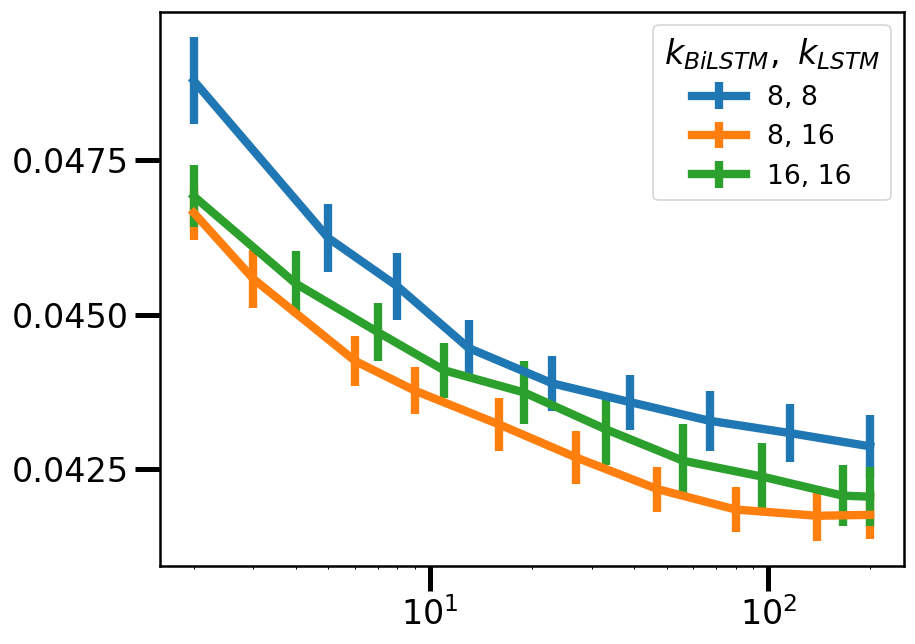

In [3]:
X_ind=np.unique(np.int64(np.logspace(0,np.log10(199),30)))
offset=0
for k1,k2 in [(8,8), (8,16), (16,16)]:
    H=np.zeros(200)
    H_2=np.zeros(200)
    c=0
    for i in range(1,21): #downloading the 20 random histories for each architecture
        c+=1
        h=pd.read_csv('histories/training_history_'+str(k1)+'_'+str(k2)+'_'+str(i)+'.csv')
        H+=np.array(h['val_loss'])
        H_2+=np.array(h['val_loss'])**2
    H/=c
    H_2/=c
    x_ind=np.unique([1]+list(X_ind[offset::3])+[199])
    plt.errorbar(np.arange(1,201)[x_ind],H[x_ind],yerr=(np.sqrt(H_2-H**2)/np.sqrt(c)*2)[x_ind],label=str(k1)+', '+str(k2)) #adding the 2 standard deviation error-bar
    offset+=1
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.legend(title=r'$k_{BiLSTM},\ k_{LSTM}$',title_fontsize=20)
plt.semilogx()